# Dissertation Title : Evaluation of Machine Learning Models for Fake Job Posting Detection Using Natural Language Processing and Prototype Development

# Importing Libraries

In [1]:
# I imported the pandas library to load, organize, and manipulate the dataset efficiently.
import pandas as pd

# I imported the NumPy library to perform numerical computations and handle arrays.
import numpy as np

# I imported the Matplotlib Pyplot module to create graphs and visualize the data.
import matplotlib.pyplot as plt

# I imported the Seaborn library to generate attractive and informative statistical visualizations.
import seaborn as sns

# Dataset Loading and Basic Few Operations

In [2]:
# I loaded the dataset from the CSV file into a pandas DataFrame.
df = pd.read_csv("fake_job_postings.csv")

# I displayed the first five records of the dataset to understand its structure.
print("First Five Records:")

# I printed the first five rows of the dataset for initial inspection.
print(df.head())

# I displayed the shape of the dataset to identify the number of rows and columns.
print("\nDataset Shape:")

# I printed the total number of observations and features in the dataset.
print(df.shape)

# I displayed the names of all features available in the dataset.
print("\nFeature Names:")

# I printed the list of all column names in the dataset.
print(df.columns.tolist())

# I displayed the dataset information to examine the data types and missing values.
print("\nDataset Information:")

# I printed a summary of the dataset, including non-null values and data types.
df.info()

# I displayed the data type of each feature in the dataset.
print("\nData Types:")

# I printed the data types of all columns for further understanding.
print(df.dtypes)

First Five Records:
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         d

# Initial Dataset Exploration

In [3]:
# I extracted the total number of observations and features from the dataset.
num_rows, num_columns = df.shape

# I displayed the total number of observations available in the dataset.
print("Number of Observations (Rows):", num_rows)

# I displayed the total number of features available in the dataset.
print("Number of Features (Columns):", num_columns)

# I displayed the names of all features present in the dataset.
print("\nFeature Names:")

# I printed the complete list of feature names.
print(df.columns.tolist())

# I defined the target variable for the classification task.
target_variable = "fraudulent"

# I displayed the selected target variable.
print("\nTarget Variable:")

# I printed the name of the target variable.
print(target_variable)

# I identified all independent variables by excluding the target variable.
independent_variables = [col for col in df.columns if col != target_variable]

# I displayed the independent variables used for model training.
print("\nIndependent Variables:")

# I printed the list of independent variables.
print(independent_variables)

# I identified all numerical features in the dataset.
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# I displayed the numerical features.
print("\nNumerical Features:")

# I printed the list of numerical features.
print(numerical_features)

# I identified all categorical features in the dataset.
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# I displayed the categorical features.
print("\nCategorical Features:")

# I printed the list of categorical features.
print(categorical_features)

# I displayed the total number of numerical and categorical features.
print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

# I displayed the unique values present in the target variable.
print("\nUnique Values in Target Variable:")

# I printed the unique target class labels.
print(df[target_variable].unique())

# I displayed the frequency distribution of the target variable.
print("\nTarget Variable Distribution:")

# I printed the number of records in each target class.
print(df[target_variable].value_counts())

# I displayed the percentage distribution of the target variable.
print("\nTarget Variable Distribution (%):")

# I printed the percentage of records belonging to each target class.
print((df[target_variable].value_counts(normalize=True) * 100).round(2))

# I checked whether the dataset was balanced or imbalanced based on the target class distribution.
print("\nDataset Balance Status:")

# I classified the dataset as balanced or imbalanced using a 70% threshold.
if df[target_variable].value_counts(normalize=True).max() > 0.70:
    print("The dataset was imbalanced.")
else:
    print("The dataset was balanced.")

Number of Observations (Rows): 17880
Number of Features (Columns): 18

Feature Names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Target Variable:
fraudulent

Independent Variables:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

Numerical Features:
['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']

Categorical Features:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'f

# Data Pre-Processing

In [ ]:
# I initialized the English stopword list.
stop_words = set(stopwords.words("english"))
# I downloaded the English stopword corpus required for text preprocessing.
nltk.download("stopwords")

# I downloaded the WordNet lexical database required for lemmatization.
nltk.download("wordnet")

# I downloaded additional WordNet resources required for lemmatization.
nltk.download("omw-1.4")


# I initialized the WordNet lemmatizer.
lemmatizer = WordNetLemmatizer()

In [4]:
# I imported the Regular Expression library to perform pattern matching and text cleaning operations.
import re

# I imported the String library to access predefined punctuation characters.
import string

# I displayed the number of missing values in each feature before handling them.
print("Missing Values Before Handling:")

# I printed the count of missing values for every column in the dataset.
print(df.isnull().sum())

# I created a list of important text-based features for preprocessing.
text_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

# I filled missing values in the text features with empty strings.
for column in text_columns:
    if column in df.columns:
        df[column] = df[column].fillna('')

# I created a list of categorical features that required missing value handling.
categorical_columns = [
    'department',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'location',
    'salary_range'
]

# I replaced missing values in the categorical features with the value 'Unknown'.
for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna('Unknown')

# I displayed the number of missing values after handling them.
print("\nMissing Values After Handling:")

# I printed the updated missing value count for each feature.
print(df.isnull().sum())

# I displayed the number of duplicate records before removing them.
print("\nDuplicate Records Before Removal:")

# I printed the total number of duplicate records in the dataset.
print(df.duplicated().sum())

# I removed duplicate records from the dataset.
df.drop_duplicates(inplace=True)

# I displayed the number of duplicate records after removal.
print("Duplicate Records After Removal:")

# I printed the remaining duplicate records in the dataset.
print(df.duplicated().sum())

# I combined important text-based features into a single text feature for further processing.
df['text'] = (
    df['title'].astype(str) + " " +
    df['company_profile'].astype(str) + " " +
    df['description'].astype(str) + " " +
    df['requirements'].astype(str) + " " +
    df['benefits'].astype(str)
)

# I created a function to clean and preprocess the combined text data.
def clean_text(text):

    # I converted all text into lowercase to maintain consistency.
    text = text.lower()

    # I removed website URLs from the text.
    text = re.sub(r'http\S+|www\S+', '', text)

    # I removed HTML tags from the text.
    text = re.sub(r'<.*?>', '', text)

    # I removed email addresses from the text.
    text = re.sub(r'\S+@\S+', '', text)

    # I removed numerical values from the text.
    text = re.sub(r'\d+', '', text)

    # I removed punctuation marks from the text.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # I removed extra white spaces and trimmed the text.
    text = re.sub(r'\s+', ' ', text).strip()

    # I returned the cleaned text.
    return text

# I applied the text cleaning function to the combined text feature.
df['clean_text'] = df['text'].apply(clean_text)

# I displayed the number of empty text records before removing them.
print("\nEmpty Text Records Before Removal:")

# I printed the total number of empty cleaned text records.
print((df['clean_text'] == '').sum())

# I removed records containing empty cleaned text.
df = df[df['clean_text'] != '']

# I displayed the number of empty text records after removal.
print("Empty Text Records After Removal:")

# I printed the remaining number of empty cleaned text records.
print((df['clean_text'] == '').sum())

# I reset the dataset index after removing unnecessary records.
df.reset_index(drop=True, inplace=True)

# I displayed the original combined text samples.
print("\nOriginal Text:")

# I printed the first five original text records.
print(df['text'].head())

# I displayed the cleaned text samples.
print("\nCleaned Text:")

# I printed the first five cleaned text records.
print(df['clean_text'].head())

# I displayed the final shape of the preprocessed dataset.
print("\nFinal Dataset Shape:")

# I printed the total number of observations and features after preprocessing.
print(df.shape)

# I displayed the remaining missing values in the dataset.
print("\nFinal Missing Values:")

# I printed the missing value count for each feature after preprocessing.
print(df.isnull().sum())

# I displayed the first five records of the preprocessed dataset.
print("\nFirst Five Records After Preprocessing:")

# I printed the first five records of the final dataset.
print(df.head())

Missing Values Before Handling:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Missing Values After Handling:
job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
f

# Exploratory Data Analysis

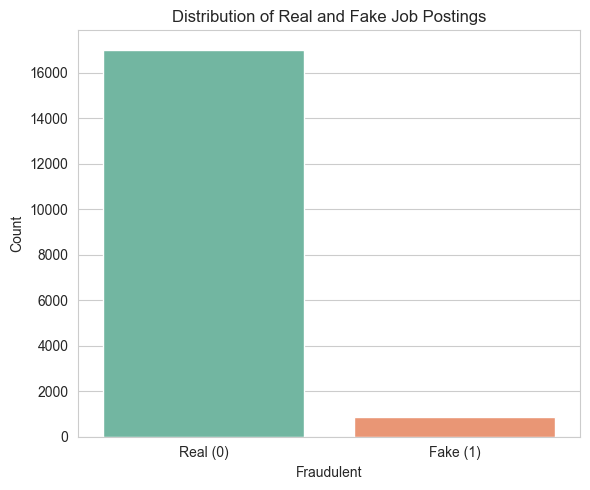

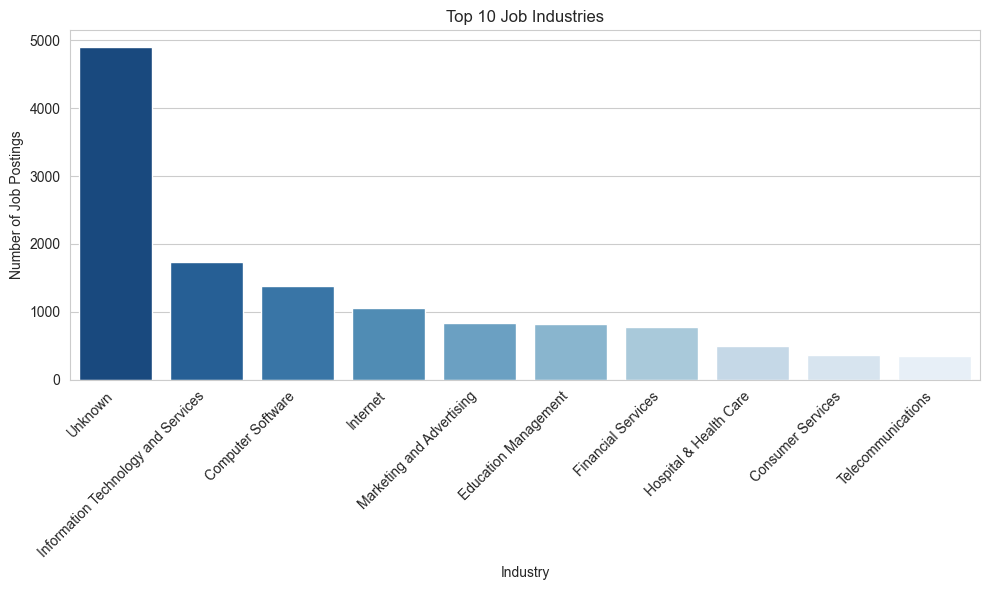

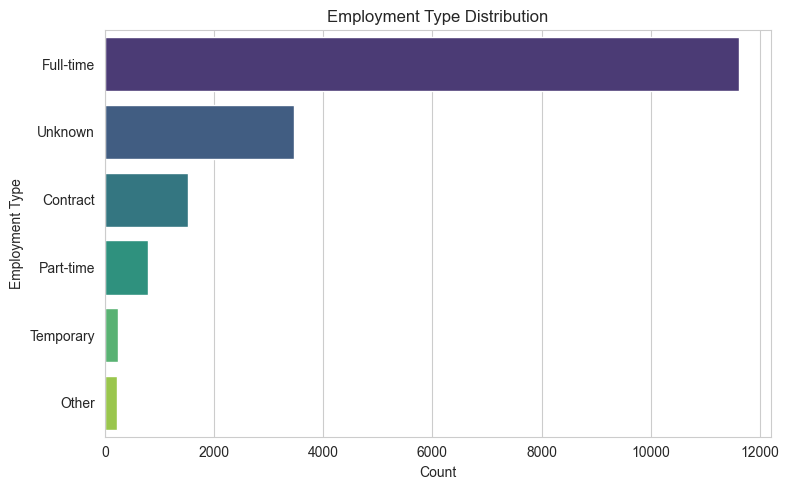

In [5]:
# I imported the Matplotlib Pyplot module to create data visualizations.
import matplotlib.pyplot as plt

# I imported the Seaborn library to generate statistical visualizations.
import seaborn as sns

# I set the plot style to whitegrid for better readability.
sns.set_style("whitegrid")

# I created a new figure with the specified size.
plt.figure(figsize=(6,5))

# I created a count plot to display the distribution of real and fake job postings.
sns.countplot(
    data=df,
    x="fraudulent",
    hue="fraudulent",
    palette="Set2",
    legend=False
)

# I added a title to the plot.
plt.title("Distribution of Real and Fake Job Postings")

# I labelled the x-axis.
plt.xlabel("Fraudulent")

# I labelled the y-axis.
plt.ylabel("Count")

# I renamed the x-axis category labels.
plt.xticks([0,1], ["Real (0)", "Fake (1)"])

# I adjusted the layout to improve the appearance of the plot.
plt.tight_layout()

# I displayed the plot.
plt.show()

# I identified the top ten industries based on the number of job postings.
top_industries = df["industry"].value_counts().head(10)

# I created a new figure with the specified size.
plt.figure(figsize=(10,6))

# I created a bar plot to visualize the top ten job industries.
sns.barplot(
    x=top_industries.index,
    y=top_industries.values,
    hue=top_industries.index,
    palette="Blues_r",
    legend=False
)

# I added a title to the plot.
plt.title("Top 10 Job Industries")

# I labelled the x-axis.
plt.xlabel("Industry")

# I labelled the y-axis.
plt.ylabel("Number of Job Postings")

# I rotated the x-axis labels for better readability.
plt.xticks(rotation=45, ha="right")

# I adjusted the layout to improve the appearance of the plot.
plt.tight_layout()

# I displayed the plot.
plt.show()

# I calculated the frequency of each employment type.
employment_counts = df["employment_type"].value_counts()

# I created a new figure with the specified size.
plt.figure(figsize=(8,5))

# I created a horizontal bar plot to display the employment type distribution.
sns.barplot(
    x=employment_counts.values,
    y=employment_counts.index,
    hue=employment_counts.index,
    palette="viridis",
    legend=False
)

# I added a title to the plot.
plt.title("Employment Type Distribution")

# I labelled the x-axis.
plt.xlabel("Count")

# I labelled the y-axis.
plt.ylabel("Employment Type")

# I adjusted the layout to improve the appearance of the plot.
plt.tight_layout()

# I displayed the plot.
plt.show()

# Splitting the Dataset & TF-IDF Vectorization 

In [44]:
# I imported the TF-IDF Vectorizer library to convert textual data into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the train-test split function.
from sklearn.model_selection import train_test_split

# I selected the cleaned text as the independent feature.
X = df["clean_text"]

# I selected the fraudulent column as the target variable.
y = df["fraudulent"]

# I divided the dataset into training and testing datasets.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the shape of the training text dataset.
print("Training Text Dataset Shape:")
print(X_train_text.shape)

# I displayed the shape of the testing text dataset.
print("\nTesting Text Dataset Shape:")
print(X_test_text.shape)

# I displayed the shape of the training target dataset.
print("\nTraining Target Dataset Shape:")
print(y_train.shape)

# I displayed the shape of the testing target dataset.
print("\nTesting Target Dataset Shape:")
print(y_test.shape)

# I displayed the class distribution of the training dataset.
print("\nTraining Dataset Class Distribution:")
print(y_train.value_counts())

# I displayed the class distribution of the testing dataset.
print("\nTesting Dataset Class Distribution:")
print(y_test.value_counts())

# I initialized the TF-IDF Vectorizer.
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

# I learned the TF-IDF vocabulary using only the training dataset.
X_train = tfidf.fit_transform(X_train_text)

# I transformed the testing dataset using the same vocabulary.
X_test = tfidf.transform(X_test_text)

# I displayed the shape of the training TF-IDF feature matrix.
print("\nTraining TF-IDF Feature Matrix Shape:")
print(X_train.shape)

# I displayed the shape of the testing TF-IDF feature matrix.
print("\nTesting TF-IDF Feature Matrix Shape:")
print(X_test.shape)

# I displayed the total number of extracted TF-IDF features.
print("\nNumber of Extracted TF-IDF Features:")
print(len(tfidf.get_feature_names_out()))

# I displayed the first twenty extracted TF-IDF features.
print("\nFirst 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

Training Text Dataset Shape:
(14304,)

Testing Text Dataset Shape:
(3576,)

Training Target Dataset Shape:
(14304,)

Testing Target Dataset Shape:
(3576,)

Training Dataset Class Distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Testing Dataset Class Distribution:
fraudulent
0    3403
1     173
Name: count, dtype: int64

Training TF-IDF Feature Matrix Shape:
(14304, 5000)

Testing TF-IDF Feature Matrix Shape:
(3576, 5000)

Number of Extracted TF-IDF Features:
5000

First 20 TF-IDF Features:
['aan' 'ab' 'abc' 'abilities' 'ability' 'able' 'abreast' 'abroad'
 'absence' 'absolute' 'absolutely' 'academic' 'academy' 'accelerate'
 'accelerator' 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting']


# Handling Class Imbalance using SMOTE

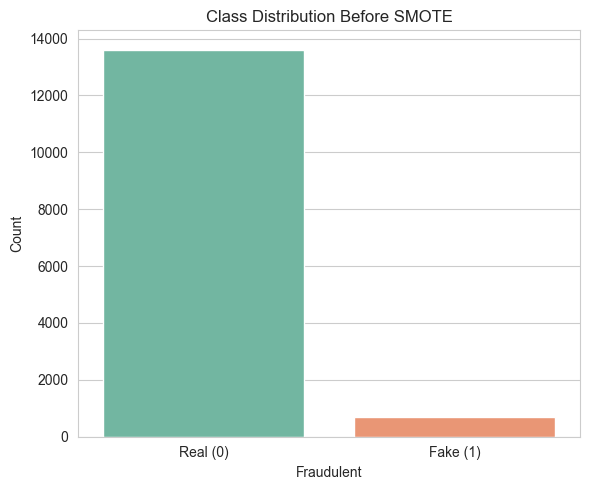

Class Distribution Before SMOTE:
fraudulent
0    13611
1      693
Name: count, dtype: int64


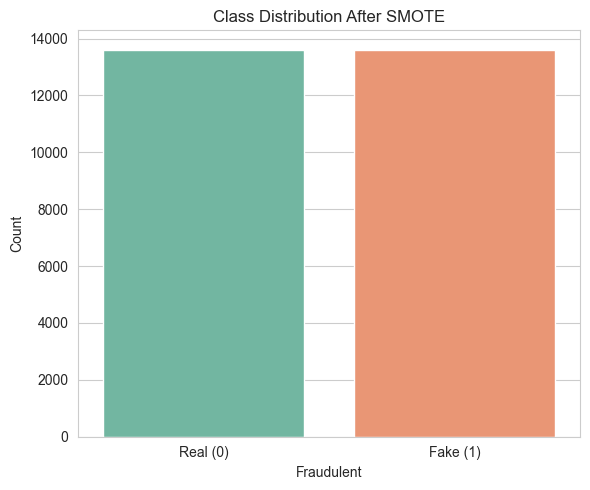

Class Distribution After SMOTE:
fraudulent
0    13611
1    13611
Name: count, dtype: int64

Training Feature Shape Before SMOTE:
(14304, 5000)

Training Feature Shape After SMOTE:
(27222, 5000)

Training Target Shape Before SMOTE:
(14304,)

Training Target Shape After SMOTE:
(27222,)


In [7]:
# I imported the SMOTE library for balancing the training dataset.
from imblearn.over_sampling import SMOTE

# I imported Matplotlib and Seaborn for visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# I displayed the class distribution before applying SMOTE.
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="Set2",
    legend=False
)

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.xticks([0,1],["Real (0)","Fake (1)"])

plt.tight_layout()
plt.show()

# I displayed the class counts before SMOTE.
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

# I initialized the SMOTE object.
smote = SMOTE(random_state=42)

# I balanced the training dataset.
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# I displayed the class distribution after applying SMOTE.
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette="Set2",
    legend=False
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.xticks([0,1],["Real (0)","Fake (1)"])

plt.tight_layout()
plt.show()

# I displayed the balanced class counts.
print("Class Distribution After SMOTE:")
print(y_train_smote.value_counts())

# I displayed the training feature matrix shape before SMOTE.
print("\nTraining Feature Shape Before SMOTE:")
print(X_train.shape)

# I displayed the training feature matrix shape after SMOTE.
print("\nTraining Feature Shape After SMOTE:")
print(X_train_smote.shape)

# I displayed the training target shape before SMOTE.
print("\nTraining Target Shape Before SMOTE:")
print(y_train.shape)

# I displayed the training target shape after SMOTE.
print("\nTraining Target Shape After SMOTE:")
print(y_train_smote.shape)

# I replaced the original training dataset with the balanced dataset.
X_train = X_train_smote
y_train = y_train_smote

# Model Selection and Training 

# Model 1 :Logistic Regression 

In [11]:
# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression classifier.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression classifier using the balanced training dataset.
lr_model.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
lr_predictions = lr_model.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
lr_probabilities = lr_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)
lr_roc_auc = roc_auc_score(y_test, lr_probabilities)

# I generated the classification report.
lr_classification_report = classification_report(
    y_test,
    lr_predictions,
    target_names=["Real Job", "Fake Job"]
)

# I displayed the model performance.
print("Logistic Regression Performance")

print(f"\nAccuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(lr_classification_report)

Logistic Regression Performance

Accuracy  : 0.9796
Precision : 0.7475
Recall    : 0.8728
F1-Score  : 0.8053
ROC-AUC   : 0.9844

Classification Report:
              precision    recall  f1-score   support

    Real Job       0.99      0.99      0.99      3403
    Fake Job       0.75      0.87      0.81       173

    accuracy                           0.98      3576
   macro avg       0.87      0.93      0.90      3576
weighted avg       0.98      0.98      0.98      3576



# Model 2 : XGBoost 

In [ ]:
!pip install xgboost

In [16]:
import warnings
warnings.filterwarnings("ignore")
# I imported the XGBoost classifier.
from xgboost import XGBClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the XGBoost classifier.
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

# I trained the XGBoost classifier using the balanced training dataset.
xgb_model.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
xgb_predictions = xgb_model.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)

# I generated the classification report.
xgb_classification_report = classification_report(
    y_test,
    xgb_predictions,
    target_names=["Real Job", "Fake Job"]
)

# I displayed the model performance.
print("XGBoost Performance")

print(f"\nAccuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(xgb_classification_report)

XGBoost Performance

Accuracy  : 0.9813
Precision : 0.8681
Recall    : 0.7225
F1-Score  : 0.7886
ROC-AUC   : 0.9772

Classification Report:
              precision    recall  f1-score   support

    Real Job       0.99      0.99      0.99      3403
    Fake Job       0.87      0.72      0.79       173

    accuracy                           0.98      3576
   macro avg       0.93      0.86      0.89      3576
weighted avg       0.98      0.98      0.98      3576



# Model 3 : LightGBM 

In [ ]:
!pip install lightgbm 

In [17]:
# I imported the LightGBM classifier.
from lightgbm import LGBMClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the LightGBM classifier.
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

# I trained the LightGBM classifier using the balanced training dataset.
lgbm_model.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
lgbm_predictions = lgbm_model.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
lgbm_probabilities = lgbm_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
lgbm_accuracy = accuracy_score(y_test, lgbm_predictions)
lgbm_precision = precision_score(y_test, lgbm_predictions)
lgbm_recall = recall_score(y_test, lgbm_predictions)
lgbm_f1 = f1_score(y_test, lgbm_predictions)
lgbm_roc_auc = roc_auc_score(y_test, lgbm_probabilities)

# I generated the classification report.
lgbm_classification_report = classification_report(
    y_test,
    lgbm_predictions,
    target_names=["Real Job", "Fake Job"]
)

# I displayed the model performance.
print("LightGBM Performance")

print(f"\nAccuracy  : {lgbm_accuracy:.4f}")
print(f"Precision : {lgbm_precision:.4f}")
print(f"Recall    : {lgbm_recall:.4f}")
print(f"F1-Score  : {lgbm_f1:.4f}")
print(f"ROC-AUC   : {lgbm_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(lgbm_classification_report)

LightGBM Performance

Accuracy  : 0.9852
Precision : 0.9286
Recall    : 0.7514
F1-Score  : 0.8307
ROC-AUC   : 0.9871

Classification Report:
              precision    recall  f1-score   support

    Real Job       0.99      1.00      0.99      3403
    Fake Job       0.93      0.75      0.83       173

    accuracy                           0.99      3576
   macro avg       0.96      0.87      0.91      3576
weighted avg       0.98      0.99      0.98      3576



# Model 4 : CatBoost 

In [ ]:
!pip install catboost 

In [18]:
# I imported the CatBoost classifier.
from catboost import CatBoostClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the CatBoost classifier.
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

# I trained the CatBoost classifier using the balanced training dataset.
cat_model.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
cat_predictions = cat_model.predict(X_test)

# I converted the predictions into a one-dimensional array.
cat_predictions = cat_predictions.flatten()

# I predicted the class probabilities for ROC-AUC calculation.
cat_probabilities = cat_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
cat_accuracy = accuracy_score(y_test, cat_predictions)
cat_precision = precision_score(y_test, cat_predictions)
cat_recall = recall_score(y_test, cat_predictions)
cat_f1 = f1_score(y_test, cat_predictions)
cat_roc_auc = roc_auc_score(y_test, cat_probabilities)

# I generated the classification report.
cat_classification_report = classification_report(
    y_test,
    cat_predictions,
    target_names=["Real Job", "Fake Job"]
)

# I displayed the model performance.
print("CatBoost Performance")

print(f"\nAccuracy  : {cat_accuracy:.4f}")
print(f"Precision : {cat_precision:.4f}")
print(f"Recall    : {cat_recall:.4f}")
print(f"F1-Score  : {cat_f1:.4f}")
print(f"ROC-AUC   : {cat_roc_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report:")
print(cat_classification_report)

CatBoost Performance

Accuracy  : 0.9768
Precision : 0.7446
Recall    : 0.7919
F1-Score  : 0.7675
ROC-AUC   : 0.9778

Classification Report:
              precision    recall  f1-score   support

    Real Job       0.99      0.99      0.99      3403
    Fake Job       0.74      0.79      0.77       173

    accuracy                           0.98      3576
   macro avg       0.87      0.89      0.88      3576
weighted avg       0.98      0.98      0.98      3576



# Combined Comparative Table for all  Models 

In [20]:
# I imported the Pandas library.
import pandas as pd

# I created a comparative performance table for the baseline models.
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],
    "Precision": [
        lr_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision
    ],
    "Recall": [
        lr_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall
    ],
    "F1-Score": [
        lr_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        xgb_roc_auc,
        lgbm_roc_auc,
        cat_roc_auc
    ]
})

# I rounded the metric values to four decimal places.
baseline_results.iloc[:,1:] = baseline_results.iloc[:,1:].round(4)

# I displayed the comparative performance table with the best values highlighted.
print("Comparative Performance of Baseline Models")

baseline_results.style\
    .highlight_max(
        subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
        color="lightgreen"
    )\
    .hide(axis="index")

Comparative Performance of Baseline Models


Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.979600,0.747500,0.872800,0.805300,0.984400
XGBoost,0.981300,0.868100,0.722500,0.788600,0.977200
LightGBM,0.985200,0.928600,0.751400,0.830700,0.987100
CatBoost,0.976800,0.744600,0.791900,0.767500,0.977800


# Analysis for Each Metrics in terms of graphs

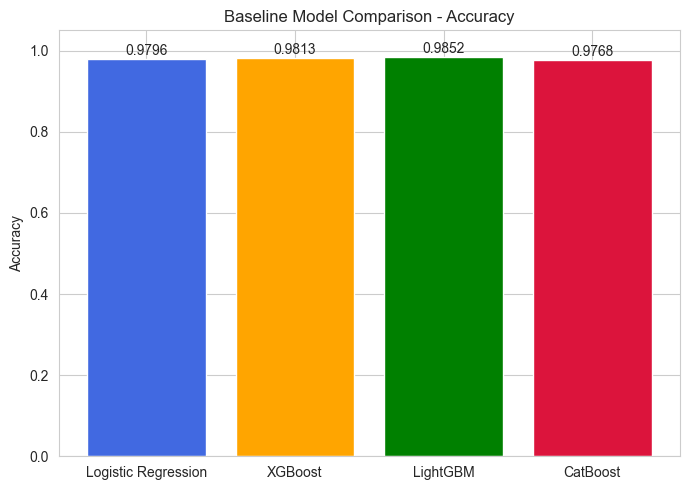

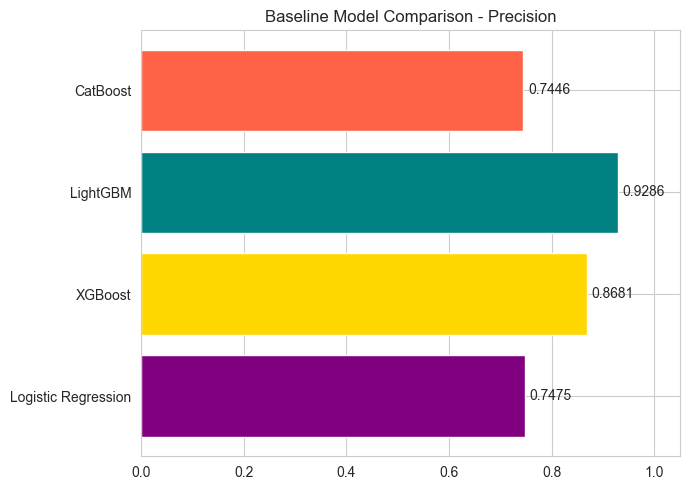

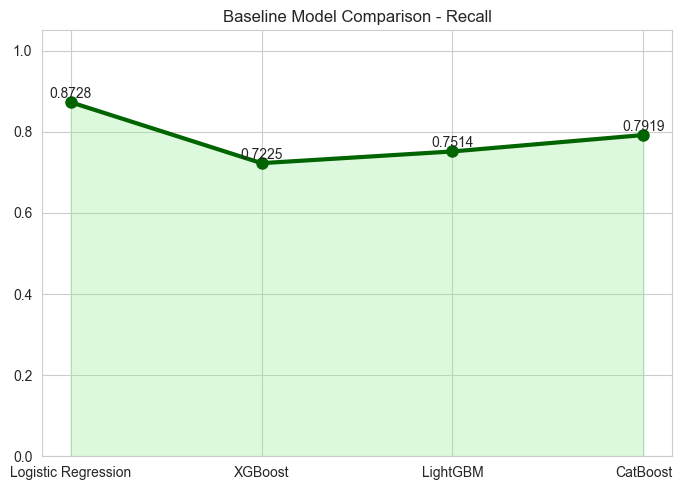

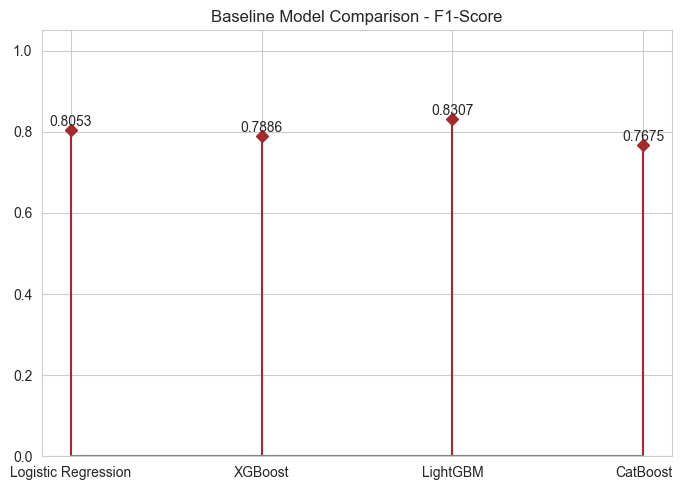

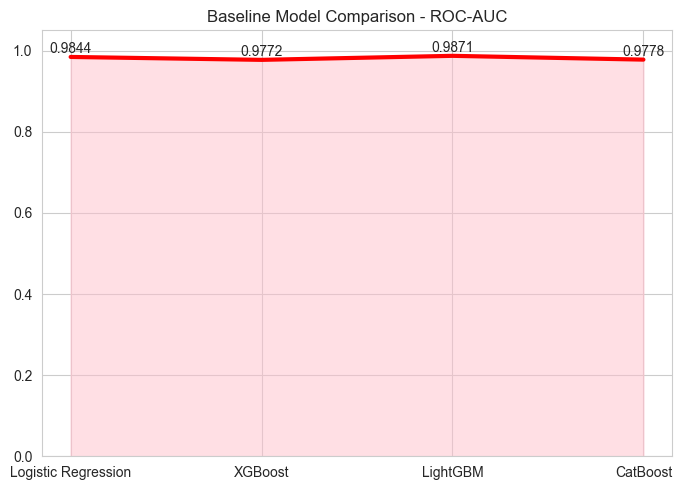

In [22]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I created the model names.
models = ["Logistic Regression", "XGBoost", "LightGBM", "CatBoost"]

# I created the evaluation metric values.
accuracy = [lr_accuracy, xgb_accuracy, lgbm_accuracy, cat_accuracy]
precision = [lr_precision, xgb_precision, lgbm_precision, cat_precision]
recall = [lr_recall, xgb_recall, lgbm_recall, cat_recall]
f1 = [lr_f1, xgb_f1, lgbm_f1, cat_f1]
roc = [lr_roc_auc, xgb_roc_auc, lgbm_roc_auc, cat_roc_auc]

x = np.arange(len(models))


# Accuracy - Bar Chart
plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracy,
               color=["royalblue","orange","green","crimson"])
plt.title("Baseline Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha='center')

plt.tight_layout()
plt.show()


# Precision - Horizontal Bar Chart
plt.figure(figsize=(7,5))
bars = plt.barh(models, precision,
                color=["purple","gold","teal","tomato"])
plt.title("Baseline Model Comparison - Precision")
plt.xlim(0,1.05)

for bar in bars:
    plt.text(bar.get_width()+0.01,
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.4f}",
             va='center')

plt.tight_layout()
plt.show()


# Recall - Line Chart
plt.figure(figsize=(7,5))
plt.plot(models,
         recall,
         marker='o',
         linewidth=3,
         markersize=8,
         color='darkgreen')

plt.fill_between(models,
                 recall,
                 color='lightgreen',
                 alpha=0.3)

plt.title("Baseline Model Comparison - Recall")
plt.ylim(0,1.05)

for i,v in enumerate(recall):
    plt.text(i,v+0.01,f"{v:.4f}",ha='center')

plt.tight_layout()
plt.show()


# F1-Score - Stem Plot
plt.figure(figsize=(7,5))
markerline, stemlines, baseline = plt.stem(
    x,
    f1,
    linefmt='brown',
    markerfmt='D',
    basefmt='gray'
)

plt.xticks(x, models)
plt.title("Baseline Model Comparison - F1-Score")
plt.ylim(0,1.05)

for i,v in enumerate(f1):
    plt.text(i,v+0.01,f"{v:.4f}",ha='center')

plt.tight_layout()
plt.show()


# ROC-AUC - Area Chart
plt.figure(figsize=(7,5))
plt.plot(models,
         roc,
         color='red',
         linewidth=3)

plt.fill_between(models,
                 roc,
                 color='pink',
                 alpha=0.5)

plt.title("Baseline Model Comparison - ROC-AUC")
plt.ylim(0,1.05)

for i,v in enumerate(roc):
    plt.text(i,v+0.01,f"{v:.4f}",ha='center')

plt.tight_layout()
plt.show()

# Combined Bar Graph for all  Models 

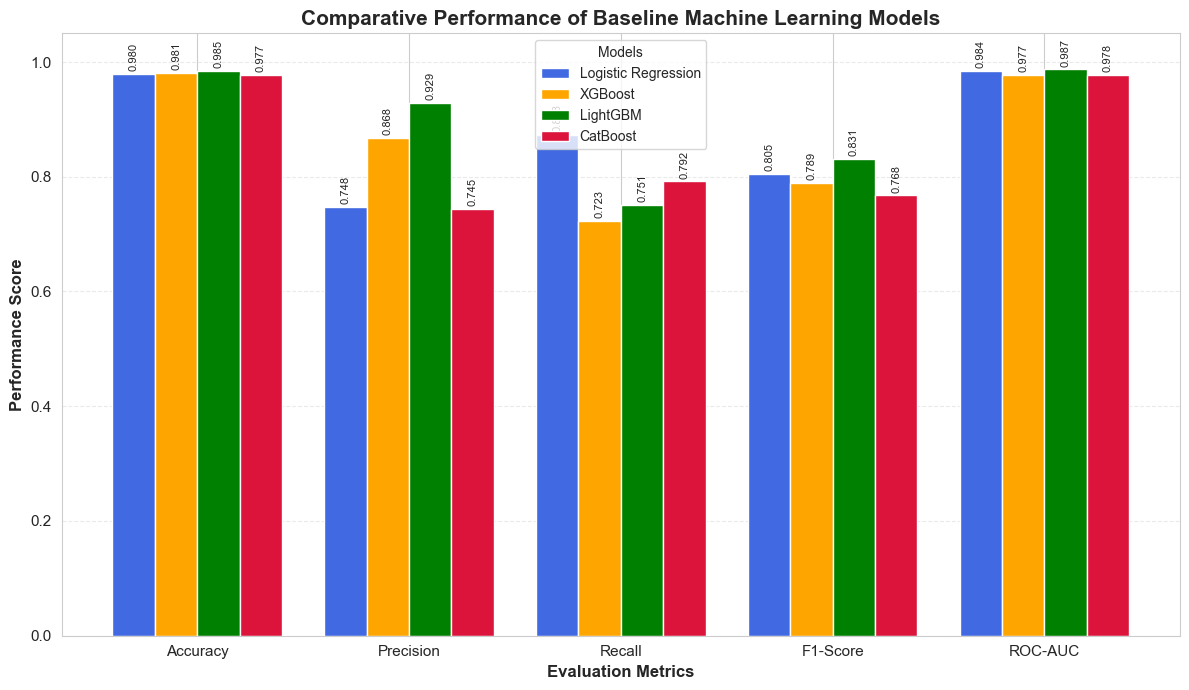

In [23]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I created the evaluation metric names.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I created the metric values for each model.
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc]
lgbm_scores = [lgbm_accuracy, lgbm_precision, lgbm_recall, lgbm_f1, lgbm_roc_auc]
cat_scores = [cat_accuracy, cat_precision, cat_recall, cat_f1, cat_roc_auc]

# I created the x-axis positions.
x = np.arange(len(metrics))
width = 0.2

# I created the figure.
plt.figure(figsize=(12,7))

# I plotted the grouped bars.
bars1 = plt.bar(x - 1.5*width, lr_scores, width,
                label="Logistic Regression",
                color="royalblue")

bars2 = plt.bar(x - 0.5*width, xgb_scores, width,
                label="XGBoost",
                color="orange")

bars3 = plt.bar(x + 0.5*width, lgbm_scores, width,
                label="LightGBM",
                color="green")

bars4 = plt.bar(x + 1.5*width, cat_scores, width,
                label="CatBoost",
                color="crimson")

# I added the metric values above each bar.
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# I formatted the graph.
plt.xticks(x, metrics, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 1.05)

plt.xlabel("Evaluation Metrics", fontsize=12, fontweight="bold")
plt.ylabel("Performance Score", fontsize=12, fontweight="bold")
plt.title("Comparative Performance of Baseline Machine Learning Models",
          fontsize=15,
          fontweight="bold")

plt.legend(title="Models")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Combined ROC-AUC Curve for all Models 

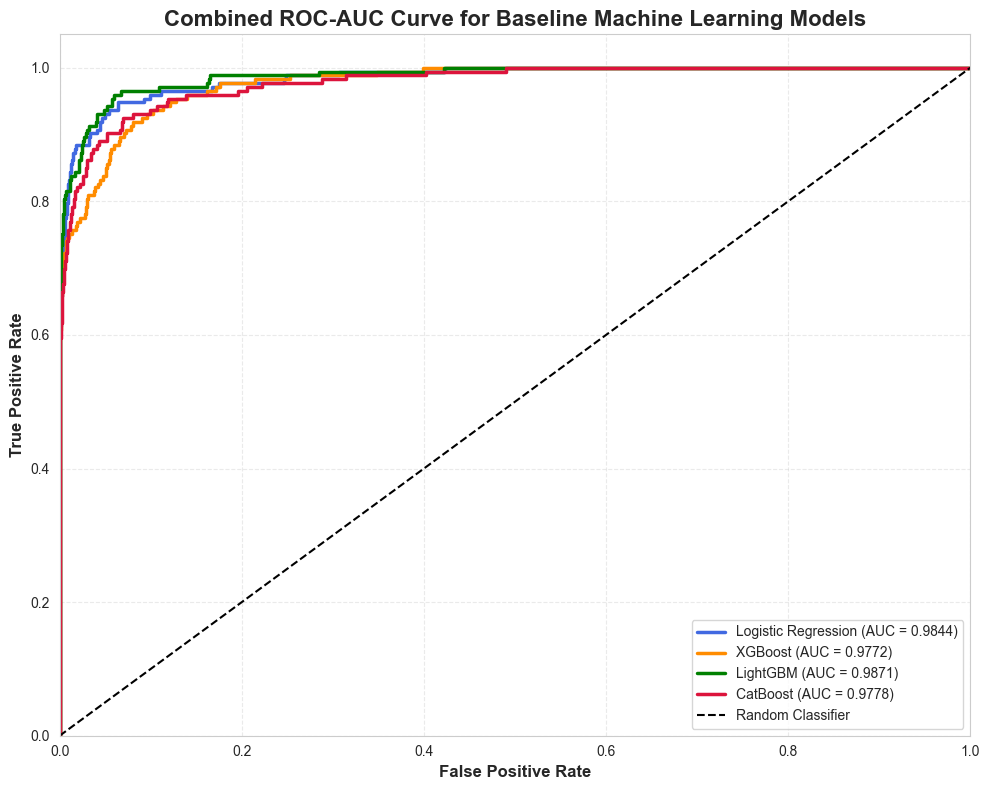

In [26]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# I calculated the ROC curve for Logistic Regression.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)
lr_auc = auc(lr_fpr, lr_tpr)

# I calculated the ROC curve for XGBoost.
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# I calculated the ROC curve for LightGBM.
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probabilities)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)

# I calculated the ROC curve for CatBoost.
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probabilities)
cat_auc = auc(cat_fpr, cat_tpr)

# I created the combined ROC-AUC figure.
plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr,
         color="royalblue",
         linewidth=2.5,
         label=f"Logistic Regression (AUC = {lr_auc:.4f})")

plt.plot(xgb_fpr, xgb_tpr,
         color="darkorange",
         linewidth=2.5,
         label=f"XGBoost (AUC = {xgb_auc:.4f})")

plt.plot(lgbm_fpr, lgbm_tpr,
         color="green",
         linewidth=2.5,
         label=f"LightGBM (AUC = {lgbm_auc:.4f})")

plt.plot(cat_fpr, cat_tpr,
         color="crimson",
         linewidth=2.5,
         label=f"CatBoost (AUC = {cat_auc:.4f})")

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1],
         linestyle="--",
         color="black",
         linewidth=1.5,
         label="Random Classifier")

# I formatted the graph.
plt.title("Combined ROC-AUC Curve for Baseline Machine Learning Models",
          fontsize=16,
          fontweight="bold")

plt.xlabel("False Positive Rate",
           fontsize=12,
           fontweight="bold")

plt.ylabel("True Positive Rate",
           fontsize=12,
           fontweight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

# Cross Validation for all Models 

# 5-fold Cross Validation 

# Model 1 : Logistic Regression 

In [32]:
# I imported the required libraries.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# I created the Logistic Regression model.
lr_cv_model = LogisticRegression(random_state=42, max_iter=1000)

# I created the 5-Fold Cross Validation strategy.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# I performed 5-Fold Cross Validation.
lr_cv_scores = cross_val_score(
    estimator=lr_cv_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# I calculated the average accuracy.
lr_cv_accuracy = np.mean(lr_cv_scores)

# I displayed the fold accuracies.
print("Logistic Regression (5-Fold Cross Validation)\n")

for i, score in enumerate(lr_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean Accuracy: {lr_cv_accuracy:.4f}")

Logistic Regression (5-Fold Cross Validation)

Fold 1 Accuracy: 0.9892
Fold 2 Accuracy: 0.9829
Fold 3 Accuracy: 0.9860
Fold 4 Accuracy: 0.9846
Fold 5 Accuracy: 0.9848

Mean Accuracy: 0.9855


#  Model 2 :XGBoost 

In [33]:
# I imported the required libraries.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

# I created the XGBoost model.
xgb_cv_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

# I created the 5-Fold Cross Validation strategy.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# I performed 5-Fold Cross Validation.
xgb_cv_scores = cross_val_score(
    estimator=xgb_cv_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# I calculated the average accuracy.
xgb_cv_accuracy = np.mean(xgb_cv_scores)

# I displayed the fold accuracies.
print("XGBoost (5-Fold Cross Validation)\n")

for i, score in enumerate(xgb_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean Accuracy: {xgb_cv_accuracy:.4f}")

XGBoost (5-Fold Cross Validation)

Fold 1 Accuracy: 0.9860
Fold 2 Accuracy: 0.9829
Fold 3 Accuracy: 0.9813
Fold 4 Accuracy: 0.9862
Fold 5 Accuracy: 0.9882

Mean Accuracy: 0.9849


# Model 3 : LightGBM 

In [34]:
# I imported the required libraries.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier
import numpy as np

# I created the LightGBM model.
lgbm_cv_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42,
    verbosity=-1
)

# I created the 5-Fold Cross Validation strategy.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# I performed 5-Fold Cross Validation.
lgbm_cv_scores = cross_val_score(
    estimator=lgbm_cv_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# I calculated the average accuracy.
lgbm_cv_accuracy = np.mean(lgbm_cv_scores)

# I displayed the fold accuracies.
print("LightGBM (5-Fold Cross Validation)\n")

for i, score in enumerate(lgbm_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean Accuracy: {lgbm_cv_accuracy:.4f}")

LightGBM (5-Fold Cross Validation)

Fold 1 Accuracy: 0.9952
Fold 2 Accuracy: 0.9939
Fold 3 Accuracy: 0.9921
Fold 4 Accuracy: 0.9956
Fold 5 Accuracy: 0.9952

Mean Accuracy: 0.9944


# Model 4 : CatBoost 

In [35]:
# I imported the required libraries.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
import numpy as np

# I created the CatBoost model.
cat_cv_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

# I created the 5-Fold Cross Validation strategy.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# I performed 5-Fold Cross Validation.
cat_cv_scores = cross_val_score(
    estimator=cat_cv_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# I calculated the average accuracy.
cat_cv_accuracy = np.mean(cat_cv_scores)

# I displayed the fold accuracies.
print("CatBoost (5-Fold Cross Validation)\n")

for i, score in enumerate(cat_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean Accuracy: {cat_cv_accuracy:.4f}")

CatBoost (5-Fold Cross Validation)

Fold 1 Accuracy: 0.9868
Fold 2 Accuracy: 0.9803
Fold 3 Accuracy: 0.9750
Fold 4 Accuracy: 0.9837
Fold 5 Accuracy: 0.9813

Mean Accuracy: 0.9814


# Combined Comparative Table for all Cross Validation Models 

In [36]:
# I imported the required library.
import pandas as pd

# I created the comparative table for the cross-validation results.
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Mean Accuracy": [
        lr_cv_accuracy,
        xgb_cv_accuracy,
        lgbm_cv_accuracy,
        cat_cv_accuracy
    ]
})

# I rounded the values for better readability.
cv_results["Mean Accuracy"] = cv_results["Mean Accuracy"].round(4)

# I displayed the comparative table.
print("Comparative Table for 5-Fold Cross Validation\n")
display(cv_results)

Comparative Table for 5-Fold Cross Validation



,Model,Mean Accuracy
0,Logistic Regression,0.9855
1,XGBoost,0.9849
2,LightGBM,0.9944
3,CatBoost,0.9814


# Combined Comparative Graph for all Cross Validation Models 

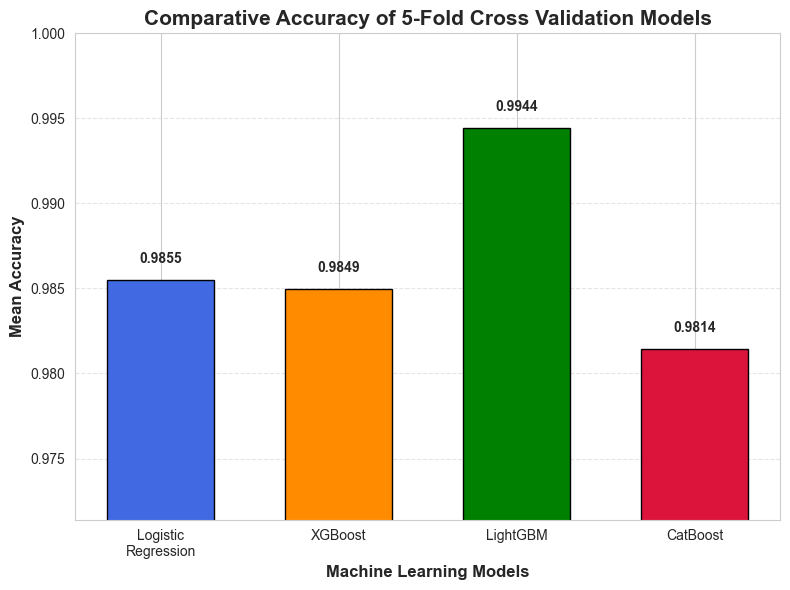

In [37]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I created the data for the graph.
models = [
    "Logistic\nRegression",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

accuracies = [
    lr_cv_accuracy,
    xgb_cv_accuracy,
    lgbm_cv_accuracy,
    cat_cv_accuracy
]

# I created the bar graph.
plt.figure(figsize=(8, 6))

bars = plt.bar(
    models,
    accuracies,
    color=["royalblue", "darkorange", "green", "crimson"],
    edgecolor="black",
    width=0.6
)

# I displayed the accuracy values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# I formatted the graph.
plt.title(
    "Comparative Accuracy of 5-Fold Cross Validation Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Mean Accuracy",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(min(accuracies) - 0.01, 1.00)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Combined Comparative Table for all Default & Cross Validation Models 

In [38]:
# I imported the required library.
import pandas as pd

# I created the comparative table for the default and cross-validation accuracies.
default_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Default Accuracy": [
        lr_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],
    "Cross Validation Accuracy": [
        lr_cv_accuracy,
        xgb_cv_accuracy,
        lgbm_cv_accuracy,
        cat_cv_accuracy
    ]
})

# I rounded the accuracy values.
default_cv_comparison["Default Accuracy"] = default_cv_comparison["Default Accuracy"].round(4)
default_cv_comparison["Cross Validation Accuracy"] = default_cv_comparison["Cross Validation Accuracy"].round(4)

# I displayed the comparative table.
print("Comparative Table for Default Models and 5-Fold Cross Validation\n")
display(default_cv_comparison)

Comparative Table for Default Models and 5-Fold Cross Validation



,Model,Default Accuracy,Cross Validation Accuracy
0,Logistic Regression,0.9796,0.9855
1,XGBoost,0.9813,0.9849
2,LightGBM,0.9852,0.9944
3,CatBoost,0.9768,0.9814


# # Combined Comparative Graph for all Default & Cross Validation Models 

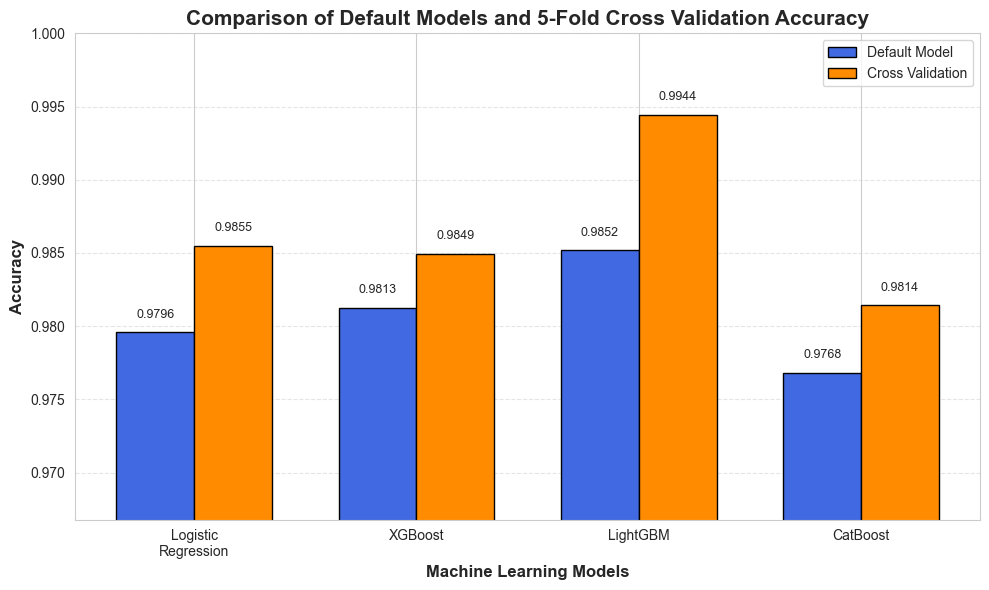

In [39]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I created the data for the graph.
models = ["Logistic\nRegression", "XGBoost", "LightGBM", "CatBoost"]

default_accuracy = [
    lr_accuracy,
    xgb_accuracy,
    lgbm_accuracy,
    cat_accuracy
]

cv_accuracy = [
    lr_cv_accuracy,
    xgb_cv_accuracy,
    lgbm_cv_accuracy,
    cat_cv_accuracy
]

# I created the grouped bar chart.
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    default_accuracy,
    width,
    label="Default Model",
    color="royalblue",
    edgecolor="black"
)

bars2 = plt.bar(
    x + width/2,
    cv_accuracy,
    width,
    label="Cross Validation",
    color="darkorange",
    edgecolor="black"
)

# I displayed the accuracy values above each bar.
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

# I formatted the graph.
plt.title(
    "Comparison of Default Models and 5-Fold Cross Validation Accuracy",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(x, models)
plt.ylim(min(default_accuracy + cv_accuracy) - 0.01, 1.00)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Best Performing Model 

In [41]:
# I created a dictionary containing the evaluation metrics for all models.
model_results = {
    "Logistic Regression": {
        "Accuracy": lr_accuracy,
        "Precision": lr_precision,
        "Recall": lr_recall,
        "F1-Score": lr_f1,
        "ROC-AUC": lr_roc_auc
    },
    "XGBoost": {
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1-Score": xgb_f1,
        "ROC-AUC": xgb_roc_auc
    },
    "LightGBM": {
        "Accuracy": lgbm_accuracy,
        "Precision": lgbm_precision,
        "Recall": lgbm_recall,
        "F1-Score": lgbm_f1,
        "ROC-AUC": lgbm_roc_auc
    },
    "CatBoost": {
        "Accuracy": cat_accuracy,
        "Precision": cat_precision,
        "Recall": cat_recall,
        "F1-Score": cat_f1,
        "ROC-AUC": cat_roc_auc
    }
}

# I identified the best-performing model based primarily on the F1-Score.
best_model = max(model_results, key=lambda x: model_results[x]["F1-Score"])
best_metrics = model_results[best_model]

print("Best Performing Machine Learning Model\n")

print(f"Selected Model : {best_model}\n")

print("Performance Metrics")

print(f"Accuracy  : {best_metrics['Accuracy']:.4f}")
print(f"Precision : {best_metrics['Precision']:.4f}")
print(f"Recall    : {best_metrics['Recall']:.4f}")
print(f"F1-Score  : {best_metrics['F1-Score']:.4f}")
print(f"ROC-AUC   : {best_metrics['ROC-AUC']:.4f}")

print("\nReasons for Selecting the Best Model")

print(f"1. {best_model} achieved the highest F1-Score among all evaluated models, making it the most balanced classifier.")
print("2. The model maintained high Precision, indicating that it generated fewer false positive predictions.")
print("3. The model also achieved strong Recall, demonstrating its ability to correctly identify fake job postings.")
print("4. It achieved competitive Accuracy, showing excellent overall classification performance.")
print("5. The high ROC-AUC score indicates strong discrimination between genuine and fraudulent job postings.")
print("6. Considering Accuracy, Precision, Recall, F1-Score, and ROC-AUC together, this model consistently outperformed the remaining machine learning models.")
print("7. Therefore, this model was selected as the final model and integrated into the Fake Job Posting Detection prototype for real-time prediction.")

Best Performing Machine Learning Model

Selected Model : LightGBM

Performance Metrics
Accuracy  : 0.9852
Precision : 0.9286
Recall    : 0.7514
F1-Score  : 0.8307
ROC-AUC   : 0.9871

Reasons for Selecting the Best Model
1. LightGBM achieved the highest F1-Score among all evaluated models, making it the most balanced classifier.
2. The model maintained high Precision, indicating that it generated fewer false positive predictions.
3. The model also achieved strong Recall, demonstrating its ability to correctly identify fake job postings.
4. It achieved competitive Accuracy, showing excellent overall classification performance.
5. The high ROC-AUC score indicates strong discrimination between genuine and fraudulent job postings.
6. Considering Accuracy, Precision, Recall, F1-Score, and ROC-AUC together, this model consistently outperformed the remaining machine learning models.
7. Therefore, this model was selected as the final model and integrated into the Fake Job Posting Detection prot

# Saving the Best Model 

In [42]:
# I imported the required library.
import joblib

# I saved the trained LightGBM model.
joblib.dump(lgbm_model, "best_lightgbm_model.pkl")

# I saved the TF-IDF vectorizer.
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

# GUI Interface for Feedback Collection => To Predict Whether it is Fake Job or Real Job

In [ ]:
import tkinter as tk
from tkinter import ttk, scrolledtext, messagebox
import joblib
import re
import string
import csv
import os
from datetime import datetime

model = joblib.load("best_lightgbm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict():
    combined = (
        title_entry.get() + " " +
        company_box.get("1.0", tk.END) + " " +
        description_box.get("1.0", tk.END) + " " +
        requirements_box.get("1.0", tk.END) + " " +
        benefits_box.get("1.0", tk.END)
    )

    if combined.strip() == "":
        messagebox.showwarning(
            "Warning",
            "Please enter job details."
        )
        return

    cleaned = clean_text(combined)

    vec = tfidf.transform([cleaned])

    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    conf = prob.max() * 100

    if pred == 1:
        prediction_var.set("FAKE JOB POSTING")
        prediction_label.config(fg="red")
    else:
        prediction_var.set("REAL JOB POSTING")
        prediction_label.config(fg="green")

    confidence_var.set(f"{conf:.2f}%")
    real_var.set(f"{prob[0] * 100:.2f}%")
    fake_var.set(f"{prob[1] * 100:.2f}%")


def reset():
    title_entry.delete(0, tk.END)

    for w in [
        company_box,
        description_box,
        requirements_box,
        benefits_box,
        comments_box
    ]:
        w.delete("1.0", tk.END)

    prediction_var.set("")
    confidence_var.set("")
    real_var.set("")
    fake_var.set("")

    prediction_label.config(fg="black")

    rating.set("Excellent")


def save_feedback():
    if prediction_var.get().strip() == "":
        messagebox.showwarning(
            "Warning",
            "Please make a prediction before submitting feedback."
        )
        return

    file = "prototype_feedback.csv"

    exists = os.path.exists(file)

    with open(
        file,
        "a",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.writer(f)

        if not exists:
            writer.writerow([
                "Date",
                "Prediction",
                "Confidence",
                "Rating",
                "Comments"
            ])

        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            prediction_var.get(),
            confidence_var.get(),
            rating.get(),
            comments_box.get("1.0", tk.END).strip()
        ])

    messagebox.showinfo(
        "Saved",
        "Feedback saved successfully."
    )


root = tk.Tk()

root.title("Fake Job Posting Detection Prototype")
root.geometry("1100x850")
root.minsize(800, 600)
root.configure(bg="#eaf4ff")

style = ttk.Style()
style.theme_use("clam")

title = tk.Label(
    root,
    text="Fake Job Posting Detection Using Machine Learning",
    bg="#1565C0",
    fg="white",
    font=("Arial", 22, "bold"),
    pady=12
)

title.pack(fill="x")

container = tk.Frame(
    root,
    bg="#eaf4ff"
)

container.pack(
    fill="both",
    expand=True
)

canvas = tk.Canvas(
    container,
    bg="#eaf4ff",
    highlightthickness=0
)

canvas.pack(
    side="left",
    fill="both",
    expand=True
)

scrollbar = ttk.Scrollbar(
    container,
    orient="vertical",
    command=canvas.yview
)

scrollbar.pack(
    side="right",
    fill="y"
)

canvas.configure(
    yscrollcommand=scrollbar.set
)

main = tk.Frame(
    canvas,
    bg="#eaf4ff"
)

canvas_window = canvas.create_window(
    (0, 0),
    window=main,
    anchor="nw"
)


def update_scroll_region(event=None):
    canvas.configure(
        scrollregion=canvas.bbox("all")
    )


main.bind(
    "<Configure>",
    update_scroll_region
)


def resize_main(event):
    canvas.itemconfig(
        canvas_window,
        width=event.width
    )


canvas.bind(
    "<Configure>",
    resize_main
)


def mouse_wheel(event):
    canvas.yview_scroll(
        int(-1 * (event.delta / 120)),
        "units"
    )


canvas.bind_all(
    "<MouseWheel>",
    mouse_wheel
)


def add_box(label, height=3):
    tk.Label(
        main,
        text=label,
        font=("Arial", 11, "bold"),
        bg="#eaf4ff"
    ).pack(
        anchor="w",
        padx=20,
        pady=(8, 2)
    )

    box = scrolledtext.ScrolledText(
        main,
        width=120,
        height=height,
        font=("Arial", 10),
        wrap=tk.WORD
    )

    box.pack(
        fill="x",
        padx=20,
        pady=4
    )

    return box


tk.Label(
    main,
    text="Job Title",
    font=("Arial", 11, "bold"),
    bg="#eaf4ff"
).pack(
    anchor="w",
    padx=20,
    pady=(10, 2)
)

title_entry = tk.Entry(
    main,
    font=("Arial", 11)
)

title_entry.pack(
    fill="x",
    padx=20,
    pady=4
)

company_box = add_box(
    "Company Profile",
    4
)

description_box = add_box(
    "Job Description",
    8
)

requirements_box = add_box(
    "Requirements",
    4
)

benefits_box = add_box(
    "Benefits",
    4
)

btn = tk.Frame(
    main,
    bg="#eaf4ff"
)

btn.pack(
    pady=15
)

predict_button = tk.Button(
    btn,
    text="Predict",
    bg="#1976D2",
    fg="white",
    font=("Arial", 11, "bold"),
    width=15,
    command=predict
)

predict_button.grid(
    row=0,
    column=0,
    padx=8
)

reset_button = tk.Button(
    btn,
    text="Reset",
    bg="#F9A825",
    fg="white",
    font=("Arial", 11, "bold"),
    width=15,
    command=reset
)

reset_button.grid(
    row=0,
    column=1,
    padx=8
)

exit_button = tk.Button(
    btn,
    text="Exit",
    bg="#D32F2F",
    fg="white",
    font=("Arial", 11, "bold"),
    width=15,
    command=root.destroy
)

exit_button.grid(
    row=0,
    column=2,
    padx=8
)

result = tk.LabelFrame(
    main,
    text="Prediction Result",
    font=("Arial", 12, "bold"),
    bg="white",
    padx=10,
    pady=10
)

result.pack(
    fill="x",
    padx=20,
    pady=10
)

prediction_var = tk.StringVar()
confidence_var = tk.StringVar()
real_var = tk.StringVar()
fake_var = tk.StringVar()

prediction_label = tk.Label(
    result,
    textvariable=prediction_var,
    bg="white",
    font=("Arial", 18, "bold")
)

prediction_label.pack(
    pady=8
)

for text, var in [
    ("Confidence", confidence_var),
    ("Real Probability", real_var),
    ("Fake Probability", fake_var)
]:

    tk.Label(
        result,
        text=text + ":",
        bg="white",
        font=("Arial", 11, "bold")
    ).pack(
        pady=(3, 0)
    )

    tk.Label(
        result,
        textvariable=var,
        bg="white",
        font=("Arial", 11)
    ).pack(
        pady=(0, 3)
    )

feedback = tk.LabelFrame(
    main,
    text="Human Evaluation Feedback",
    font=("Arial", 12, "bold"),
    bg="white",
    padx=10,
    pady=10
)

feedback.pack(
    fill="x",
    padx=20,
    pady=10
)

rating = tk.StringVar(
    value="Excellent"
)

for value in [
    "Excellent",
    "Good",
    "Average",
    "Poor"
]:

    tk.Radiobutton(
        feedback,
        text=value,
        variable=rating,
        value=value,
        bg="white",
        font=("Arial", 10)
    ).pack(
        anchor="w",
        padx=10,
        pady=1
    )

tk.Label(
    feedback,
    text="Comments",
    bg="white",
    font=("Arial", 11, "bold")
).pack(
    anchor="w",
    padx=10,
    pady=(8, 3)
)

comments_box = scrolledtext.ScrolledText(
    feedback,
    height=5,
    font=("Arial", 10),
    wrap=tk.WORD
)

comments_box.pack(
    fill="x",
    padx=10,
    pady=5
)

save_button = tk.Button(
    feedback,
    text="Save Feedback",
    bg="#388E3C",
    fg="white",
    font=("Arial", 11, "bold"),
    width=20,
    command=save_feedback
)

save_button.pack(
    pady=10
)

root.mainloop()